In [90]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import adfuller

In [2]:
fact_budget=pd.read_csv('dwhVF/fact_eventbudget.csv')

In [3]:
dim_date= pd.read_csv('dwhVF/dim_date.csv')

In [18]:
fact_res=pd.read_csv('dwhVF/fact_reservation.csv')

In [19]:
fact_res = fact_res.merge(dim_date, on='id_date')

In [6]:
fact_budget.head(5)

,budget,id_categoryFK,id_cityFK,id_beneficiaryFK,id_dateFK
0,46238,3,1,2596,9188
1,42004,87,1,3560,8079
2,379020,1,1,4683,8443
3,49114,3,1,4372,8311
4,10776,87,1,834,9244


In [7]:
fact_budget =fact_budget.merge(dim_date, left_on='id_dateFK', right_on='id_date')

In [20]:
fact_res.head(5)

,final_price,id_service,id_status,id_date,id_event,id_evaluation,Date,Day,Month,Year
0,9070,575,1,8398,6547,6472,2023-03-31,31,3,2023
1,6971,361,3,8705,3677,11044,2024-02-01,1,2,2024
2,722,2246,3,8031,5789,8717,2022-03-29,29,3,2022
3,307,336,1,8878,1911,6747,2024-07-23,23,7,2024
4,5330,1068,8,8721,7604,1490,2024-02-17,17,2,2024


In [21]:
fact_res= fact_res.drop(columns=['id_service','id_status','id_date','id_event','id_evaluation','Day','Month','Year'])

In [12]:
fact_budget.head(5)

,budget,id_categoryFK,id_cityFK,id_beneficiaryFK,id_dateFK,id_date,Date,Day,Month,Year
0,46238,3,1,2596,9188,9188,2025-05-29,29,5,2025
1,42004,87,1,3560,8079,8079,2022-05-16,16,5,2022
2,379020,1,1,4683,8443,8443,2023-05-15,15,5,2023
3,49114,3,1,4372,8311,8311,2023-01-03,3,1,2023
4,10776,87,1,834,9244,9244,2025-07-24,24,7,2025


In [13]:
fact_budget= fact_budget.drop(columns=['id_categoryFK','id_cityFK','id_beneficiaryFK','id_dateFK','id_date','Day','Month','Year'])

In [14]:
fact_budget.head(5)

,budget,Date
0,46238,2025-05-29
1,42004,2022-05-16
2,379020,2023-05-15
3,49114,2023-01-03
4,10776,2025-07-24


In [22]:
fact_budget['Date'] = pd.to_datetime(fact_budget['Date'])
fact_res['Date']=pd.to_datetime(fact_res['Date'])

In [23]:
fact_res.head(5)

,final_price,Date
0,9070,2023-03-31
1,6971,2024-02-01
2,722,2022-03-29
3,307,2024-07-23
4,5330,2024-02-17


In [24]:
fact_res.rename(columns={'final_price': 'Revenue'}, inplace=True)

In [25]:
fact_res.head(5)

,Revenue,Date
0,9070,2023-03-31
1,6971,2024-02-01
2,722,2022-03-29
3,307,2024-07-23
4,5330,2024-02-17


In [26]:
fact_res = fact_res.sort_values(by='Date', ascending=True).reset_index(drop=True)

In [27]:
fact_budget = fact_budget.sort_values(by='Date', ascending=True).reset_index(drop=True)

In [29]:
fact_budget.head(5)
fact_res.head(5)

,Revenue,Date
0,8667,2022-01-01
1,10534,2022-01-01
2,9321,2022-01-01
3,1515,2022-01-01
4,3046,2022-01-02


In [30]:
fact_res.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6795 entries, 0 to 6794
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Revenue  6795 non-null   int64         
 1   Date     6795 non-null   datetime64[ns]
dtypes: datetime64[ns](1), int64(1)
memory usage: 106.3 KB


In [31]:
fact_budget.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12071 entries, 0 to 12070
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   budget  12071 non-null  int64         
 1   Date    12071 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(1)
memory usage: 188.7 KB


In [32]:
fact_res = fact_res.set_index('Date')

In [33]:
fact_budget = fact_budget.set_index('Date')

In [34]:
fact_budget.head(5)

,budget
Date,
2022-01-01,6040
2022-01-01,35507
2022-01-01,38607
2022-01-01,37492
2022-01-01,2705


In [35]:
fact_res.head(5)

,Revenue
Date,
2022-01-01,8667
2022-01-01,10534
2022-01-01,9321
2022-01-01,1515
2022-01-02,3046


In [36]:
res_resampled = fact_res.resample('ME').sum(numeric_only=True) 

In [37]:
budget_resampled = fact_budget.resample('ME').mean(numeric_only=True) 

In [38]:
res_resampled.head(5)

,Revenue
Date,
2022-01-31,1567250
2022-02-28,1693527
2022-03-31,1922248
2022-04-30,1646318
2022-05-31,1881236


In [39]:
budget_resampled.head(5)

,budget
Date,
2022-01-31,43628.175000
2022-02-28,47146.756219
2022-03-31,39753.104247
2022-04-30,48924.630952
2022-05-31,30628.165385


In [74]:
df = pd.concat([res_resampled, budget_resampled], axis=1)
df.columns = ['Revenue', 'Expenses']

In [41]:
df.head(5)

,Revenue,Expenses
Date,,
2022-01-31,1567250.0,43628.175000
2022-02-28,1693527.0,47146.756219
2022-03-31,1922248.0,39753.104247
2022-04-30,1646318.0,48924.630952
2022-05-31,1881236.0,30628.165385


REVENUE

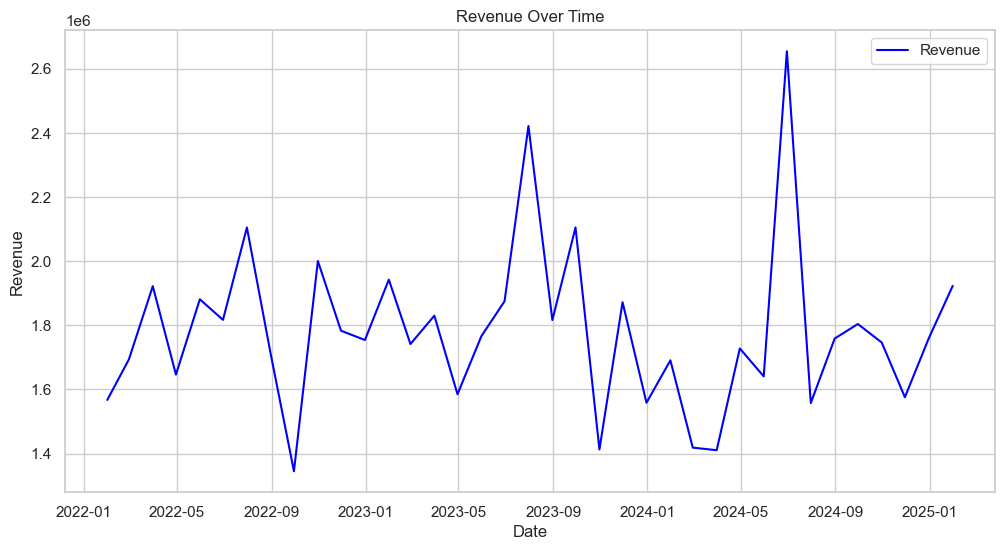

In [42]:
sns.set(style="whitegrid") 

plt.figure(figsize=(12, 6))
sns.lineplot(data=res_resampled, x=res_resampled.index, y='Revenue', label='Revenue', color='blue')

plt.xlabel('Date')
plt.ylabel('Revenue')
plt.title('Revenue Over Time')

plt.show()

'Date' is already the index or not present in the DataFrame.


<Figure size 1200x600 with 0 Axes>

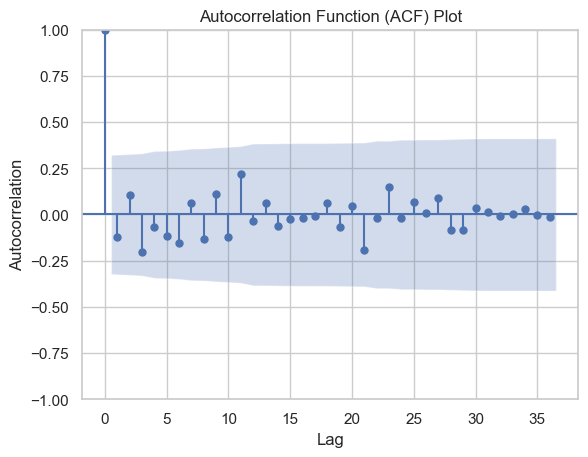

In [54]:
if 'Date' not in res_resampled.columns:
    print("'Date' is already the index or not present in the DataFrame.")
else:
    df.set_index('Date', inplace=True)

plt.figure(figsize=(12, 6))
plot_acf(res_resampled['Revenue'], lags=36)
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.title('Autocorrelation Function (ACF) Plot')
plt.show()

In [55]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(res_resampled['Revenue'])
print('ADF Statistic:', result[0])
print('p-value:', result[1])
print('Critical Values:', result[4])

ADF Statistic: -6.6150327217178955
p-value: 6.2382088419008725e-09
Critical Values: {'1%': -3.626651907578875, '5%': -2.9459512825788754, '10%': -2.6116707716049383}


Feature engineering

In [75]:
df['month'] = df.index.month
df['year'] = df.index.year
df['lag1_revenue'] = df['Revenue'].shift(1)
df['lag12_revenue'] = df['Revenue'].shift(12)
df['lag1_expenses'] = df['Expenses'].shift(1)
df['lag12_expenses'] = df['Expenses'].shift(12)

In [44]:
df.head(5)

,Revenue,Expenses,month,year,lag1_revenue,lag12_revenue,lag1_expenses,lag12_expenses
Date,,,,,,,,
2022-01-31,1567250.0,43628.175000,1,2022,NaN,NaN,NaN,NaN
2022-02-28,1693527.0,47146.756219,2,2022,1567250.0,NaN,43628.175000,NaN
2022-03-31,1922248.0,39753.104247,3,2022,1693527.0,NaN,47146.756219,NaN
2022-04-30,1646318.0,48924.630952,4,2022,1922248.0,NaN,39753.104247,NaN
2022-05-31,1881236.0,30628.165385,5,2022,1646318.0,NaN,48924.630952,NaN


In [45]:
df.head(15)

,Revenue,Expenses,month,year,lag1_revenue,lag12_revenue,lag1_expenses,lag12_expenses
Date,,,,,,,,
2022-01-31,1567250.0,43628.175000,1,2022,NaN,NaN,NaN,NaN
2022-02-28,1693527.0,47146.756219,2,2022,1567250.0,NaN,43628.175000,NaN
2022-03-31,1922248.0,39753.104247,3,2022,1693527.0,NaN,47146.756219,NaN
2022-04-30,1646318.0,48924.630952,4,2022,1922248.0,NaN,39753.104247,NaN
2022-05-31,1881236.0,30628.165385,5,2022,1646318.0,NaN,48924.630952,NaN
2022-06-30,1817060.0,37451.859316,6,2022,1881236.0,NaN,30628.165385,NaN
2022-07-31,2105235.0,41620.607438,7,2022,1817060.0,NaN,37451.859316,NaN
2022-08-31,1708814.0,57222.819742,8,2022,2105235.0,NaN,41620.607438,NaN
2022-09-30,1344809.0,51684.307359,9,2022,1708814.0,NaN,57222.819742,NaN


In [76]:
df.dropna(inplace=True)

In [77]:
df.head(15)

,Revenue,Expenses,month,year,lag1_revenue,lag12_revenue,lag1_expenses,lag12_expenses
Date,,,,,,,,
2023-01-31,1942488.0,39693.375000,1,2023,1754195.0,1567250.0,37728.238281,43628.175000
2023-02-28,1741703.0,38175.541126,2,2023,1942488.0,1693527.0,39693.375000,47146.756219
2023-03-31,1830044.0,32831.888889,3,2023,1741703.0,1922248.0,38175.541126,39753.104247
2023-04-30,1585015.0,39182.125000,4,2023,1830044.0,1646318.0,32831.888889,48924.630952
2023-05-31,1766348.0,38701.774468,5,2023,1585015.0,1881236.0,39182.125000,30628.165385
2023-06-30,1875093.0,39040.440945,6,2023,1766348.0,1817060.0,38701.774468,37451.859316
2023-07-31,2421792.0,44591.921260,7,2023,1875093.0,2105235.0,39040.440945,41620.607438
2023-08-31,1816448.0,38937.753138,8,2023,2421792.0,1708814.0,44591.921260,57222.819742
2023-09-30,2105440.0,33998.536290,9,2023,1816448.0,1344809.0,38937.753138,51684.307359


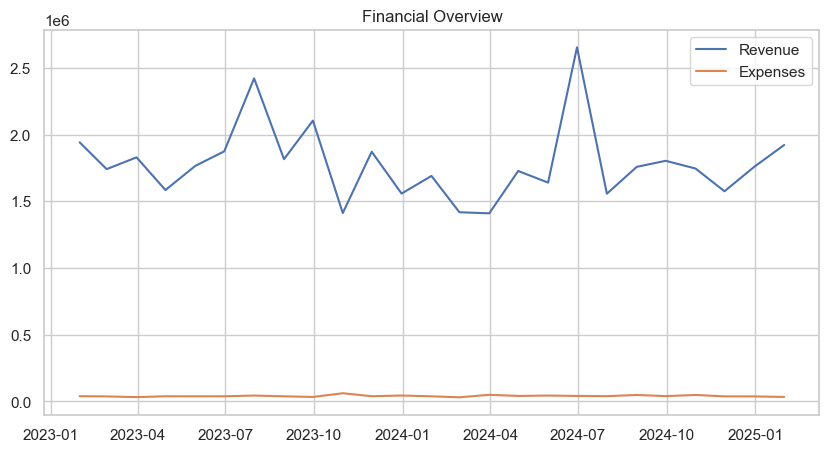

In [49]:

plt.figure(figsize=(10,5))
plt.plot(df['Revenue'], label='Revenue')
plt.plot(df['Expenses'], label='Expenses')
plt.legend()
plt.title('Financial Overview')
plt.show()

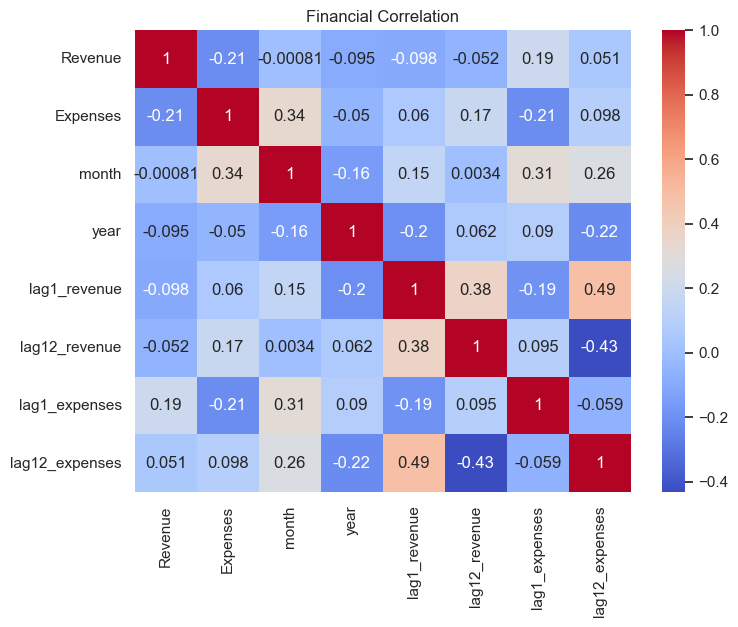

In [50]:

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Financial Correlation')
plt.show()

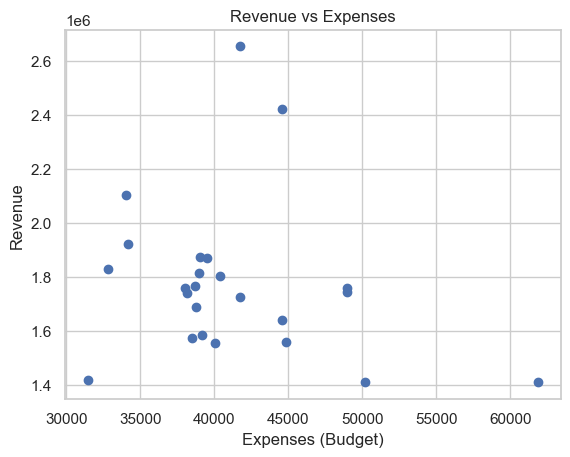

In [113]:

plt.scatter(df['Expenses'], df['Revenue'])
plt.title('Revenue vs Expenses')
plt.xlabel('Expenses (Budget)')
plt.ylabel('Revenue')
plt.show()

<Figure size 1200x600 with 0 Axes>

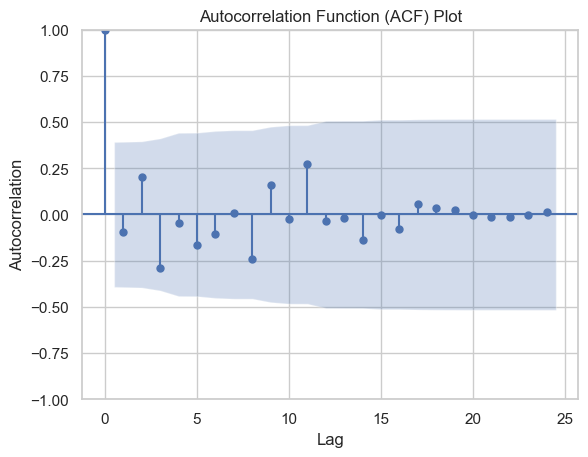

ADF Statistic: -1.2428297103699941
p-value: 0.6549055874581559
Critical Values: {'1%': -3.9644434814814815, '5%': -3.0849081481481484, '10%': -2.6818144444444445}


In [58]:
plt.figure(figsize=(12, 6))
plot_acf(df['Revenue'], lags=24)
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.title('Autocorrelation Function (ACF) Plot')
plt.show()
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['Revenue'])
print('ADF Statistic:', result[0])
print('p-value:', result[1])
print('Critical Values:', result[4])

In [79]:
df['Revenue_diff'] = df['Revenue'].diff()
df.dropna(inplace=True)

In [80]:
df['Revenue_diff'].head(5)

Date
2023-02-28   -200785.0
2023-03-31     88341.0
2023-04-30   -245029.0
2023-05-31    181333.0
2023-06-30    108745.0
Freq: ME, Name: Revenue_diff, dtype: float64

<Figure size 1200x600 with 0 Axes>

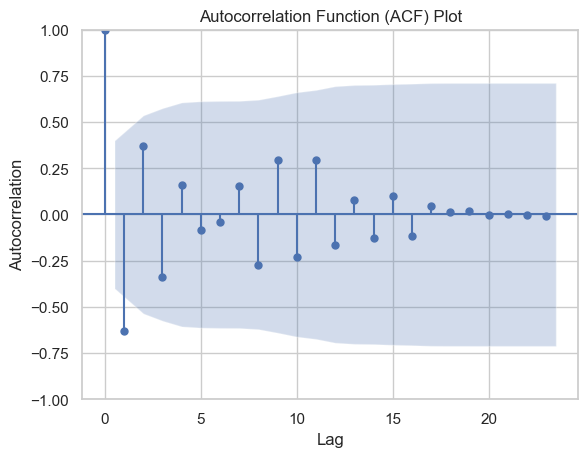

ADF Statistic: -3.4856030866981795
p-value: 0.008364627693304183
Critical Values: {'1%': -3.9644434814814815, '5%': -3.0849081481481484, '10%': -2.6818144444444445}


In [63]:
plt.figure(figsize=(12, 6))
plot_acf(df['Revenue_diff'], lags=23)
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.title('Autocorrelation Function (ACF) Plot')
plt.show()
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['Revenue_diff'])
print('ADF Statistic:', result[0])
print('p-value:', result[1])
print('Critical Values:', result[4])

In [64]:
df.head(5)

,Revenue,Expenses,month,year,lag1_revenue,lag12_revenue,lag1_expenses,lag12_expenses,Revenue_diff
Date,,,,,,,,,
2023-02-28,1741703.0,38175.541126,2,2023,1942488.0,1693527.0,39693.375000,47146.756219,-200785.0
2023-03-31,1830044.0,32831.888889,3,2023,1741703.0,1922248.0,38175.541126,39753.104247,88341.0
2023-04-30,1585015.0,39182.125000,4,2023,1830044.0,1646318.0,32831.888889,48924.630952,-245029.0
2023-05-31,1766348.0,38701.774468,5,2023,1585015.0,1881236.0,39182.125000,30628.165385,181333.0
2023-06-30,1875093.0,39040.440945,6,2023,1766348.0,1817060.0,38701.774468,37451.859316,108745.0


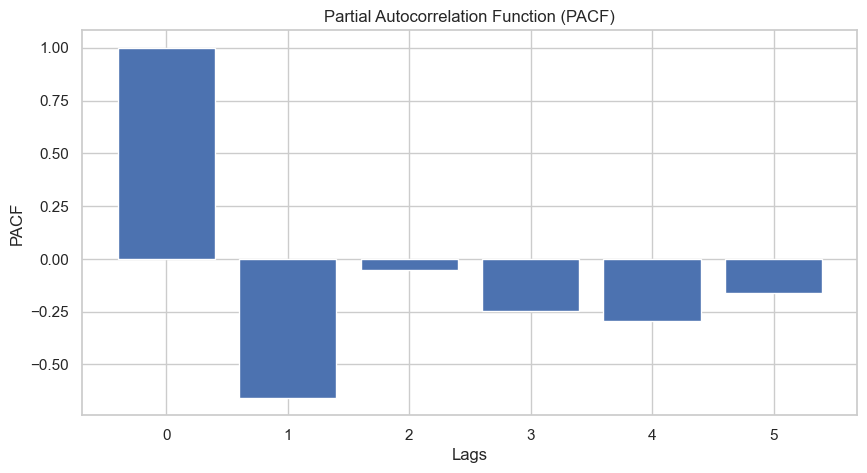

In [83]:
from statsmodels.tsa.stattools import pacf
from statsmodels.datasets import get_rdataset
# Calculate PACF using statsmodels pacf function
pacf_values = pacf(df['Revenue_diff'], nlags=5)

# Plot PACF
plt.figure(figsize=(10, 5))
plt.bar(range(len(pacf_values)), pacf_values)
plt.title('Partial Autocorrelation Function (PACF)')
plt.xlabel('Lags')
plt.ylabel('PACF')
plt.grid(True)
plt.show()



In [84]:
df

,Revenue,Expenses,month,year,lag1_revenue,lag12_revenue,lag1_expenses,lag12_expenses,Revenue_diff
Date,,,,,,,,,
2023-02-28,1741703.0,38175.541126,2,2023,1942488.0,1693527.0,39693.375000,47146.756219,-200785.0
2023-03-31,1830044.0,32831.888889,3,2023,1741703.0,1922248.0,38175.541126,39753.104247,88341.0
2023-04-30,1585015.0,39182.125000,4,2023,1830044.0,1646318.0,32831.888889,48924.630952,-245029.0
2023-05-31,1766348.0,38701.774468,5,2023,1585015.0,1881236.0,39182.125000,30628.165385,181333.0
2023-06-30,1875093.0,39040.440945,6,2023,1766348.0,1817060.0,38701.774468,37451.859316,108745.0
2023-07-31,2421792.0,44591.921260,7,2023,1875093.0,2105235.0,39040.440945,41620.607438,546699.0
2023-08-31,1816448.0,38937.753138,8,2023,2421792.0,1708814.0,44591.921260,57222.819742,-605344.0
2023-09-30,2105440.0,33998.536290,9,2023,1816448.0,1344809.0,38937.753138,51684.307359,288992.0
2023-10-31,1412741.0,61892.954545,10,2023,2105440.0,2000416.0,33998.536290,47021.921569,-692699.0


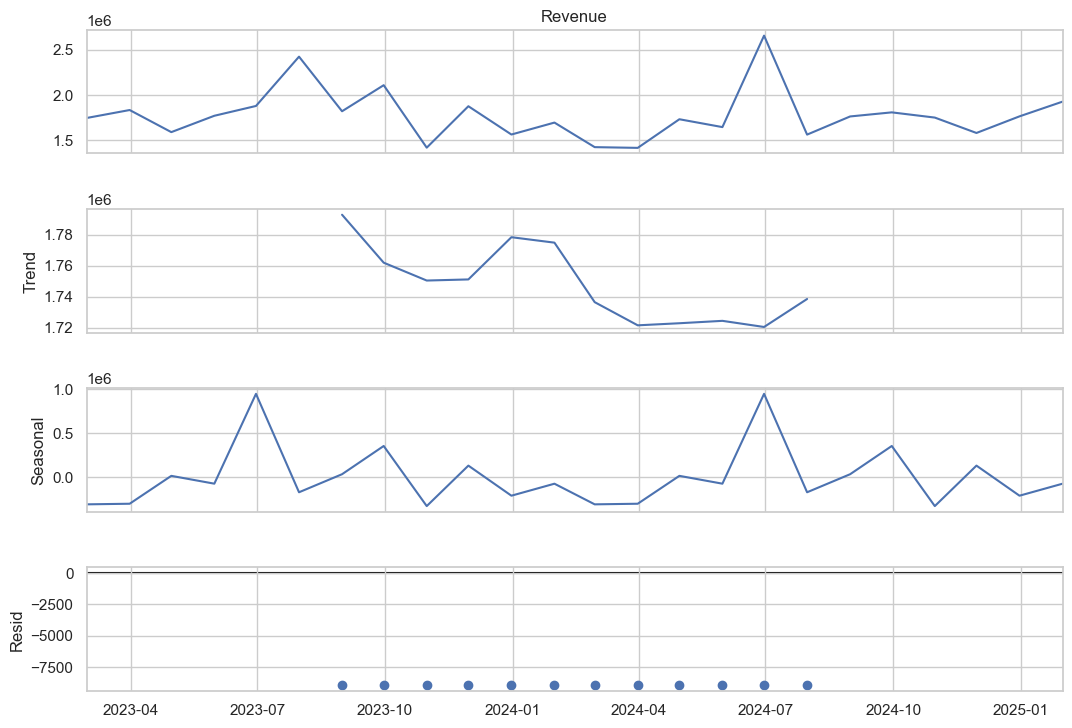

In [85]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

# Perform decomposition on RAW revenue
# Period=12 because it's monthly data
decomposition = seasonal_decompose(df['Revenue'], model='additive', period=12)

# Plot the components
fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.show()

In [91]:
train

Date
2023-02-28    1741703.0
2023-03-31    1830044.0
2023-04-30    1585015.0
2023-05-31    1766348.0
2023-06-30    1875093.0
2023-07-31    2421792.0
2023-08-31    1816448.0
2023-09-30    2105440.0
2023-10-31    1412741.0
2023-11-30    1872112.0
2023-12-31    1558454.0
2024-01-31    1690837.0
2024-02-29    1418500.0
2024-03-31    1410470.0
2024-04-30    1727850.0
2024-05-31    1640718.0
2024-06-30    2654941.0
2024-07-31    1557486.0
2024-08-31    1758837.0
2024-09-30    1804113.0
Freq: ME, Name: Revenue, dtype: float64

In [92]:
train = df[:-4]
test = df[-4:]

In [93]:
train

,Revenue,Expenses,month,year,lag1_revenue,lag12_revenue,lag1_expenses,lag12_expenses,Revenue_diff
Date,,,,,,,,,
2023-02-28,1741703.0,38175.541126,2,2023,1942488.0,1693527.0,39693.375000,47146.756219,-200785.0
2023-03-31,1830044.0,32831.888889,3,2023,1741703.0,1922248.0,38175.541126,39753.104247,88341.0
2023-04-30,1585015.0,39182.125000,4,2023,1830044.0,1646318.0,32831.888889,48924.630952,-245029.0
2023-05-31,1766348.0,38701.774468,5,2023,1585015.0,1881236.0,39182.125000,30628.165385,181333.0
2023-06-30,1875093.0,39040.440945,6,2023,1766348.0,1817060.0,38701.774468,37451.859316,108745.0
2023-07-31,2421792.0,44591.921260,7,2023,1875093.0,2105235.0,39040.440945,41620.607438,546699.0
2023-08-31,1816448.0,38937.753138,8,2023,2421792.0,1708814.0,44591.921260,57222.819742,-605344.0
2023-09-30,2105440.0,33998.536290,9,2023,1816448.0,1344809.0,38937.753138,51684.307359,288992.0
2023-10-31,1412741.0,61892.954545,10,2023,2105440.0,2000416.0,33998.536290,47021.921569,-692699.0


MODELS

In [94]:
m_arima = SARIMAX(train['Revenue'], order=(1,1,1), seasonal_order=(0,0,0,0))
res_arima = m_arima.fit(disp=False)
pred_arima = res_arima.forecast(steps=4)

In [95]:
m_sarima = SARIMAX(train['Revenue'], order=(1,1,1), seasonal_order=(0,1,0,12))
res_sarima = m_sarima.fit(disp=False)
pred_sarima = res_sarima.forecast(steps=4)

In [96]:
m3 = SARIMAX(train['Revenue'], exog=train['Expenses'], 
             order=(1, 1, 1), seasonal_order=(0, 1, 0, 12))
res3 = m3.fit(disp=False)
p3 = res3.get_forecast(steps=4, exog=test['Expenses']).predicted_mean

In [102]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
def get_metrics(true, pred, name):
    mape = np.mean(np.abs((true - pred) / true)) * 100
    rmse = np.sqrt(mean_squared_error(true, pred))
    mae = mean_absolute_error(true, pred)
    return {"Model": name, "MAPE (%)": f"{mape:.2f}%", "RMSE": f"{rmse:.2f}", "MAE": f"{mae:.2f}"}



In [112]:
comparison_results = pd.DataFrame([
    # Model 1: ARIMA
    get_metrics(test['Revenue'], 
                SARIMAX(train['Revenue'], order=(1,1,1)).fit(disp=False).forecast(4), 
                "ARIMA"),
    
    # Model 2: SARIMA
    get_metrics(test['Revenue'], 
                SARIMAX(train['Revenue'], order=(1,1,1), seasonal_order=(0,1,0,12)).fit(disp=False).forecast(4), 
                "SARIMA"),
    
    # Model 3: SARIMAX (with Expenses)
    get_metrics(test['Revenue'], 
                SARIMAX(train['Revenue'], exog=train['Expenses'], order=(1,1,1), seasonal_order=(0,1,0,12))
                .fit(disp=False).get_forecast(4, exog=test['Expenses']).predicted_mean, 
                "SARIMAX (Expenses)")
])


print("--- Final Forecast Comparison ---")
print(comparison_results)



--- Final Forecast Comparison ---
                Model MAPE (%)       RMSE        MAE
0               ARIMA    6.07%  128169.01  103375.53
1              SARIMA   21.77%  442938.96  391201.71
2  SARIMAX (Expenses)   46.00%  913735.41  820072.23


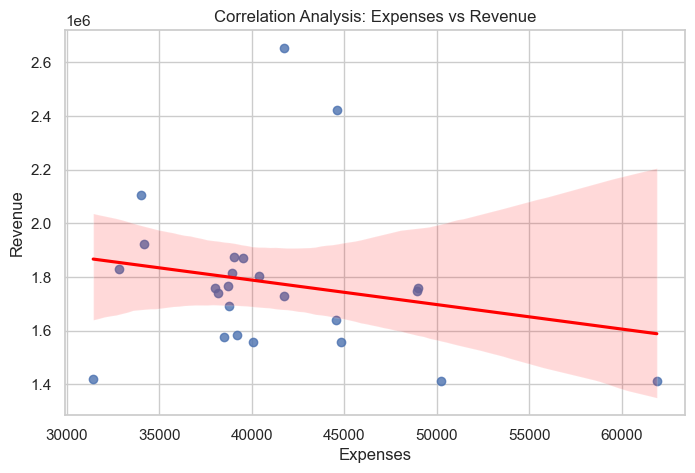

In [107]:
import seaborn as sns
plt.figure(figsize=(8, 5))
sns.regplot(x=df['Expenses'], y=df['Revenue'], line_kws={"color": "red"})
plt.title("Correlation Analysis: Expenses vs Revenue")
plt.show()

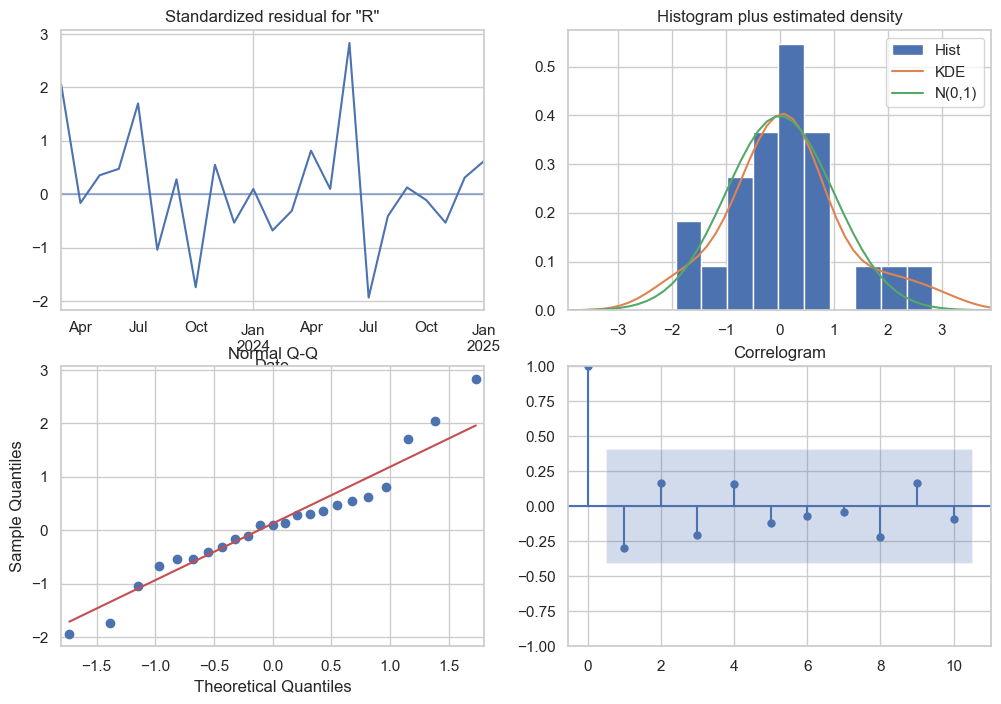

In [109]:

choice = SARIMAX(df['Revenue'], order=(1,1,1)).fit(disp=False)
choice.plot_diagnostics(figsize=(12, 8))
plt.show()

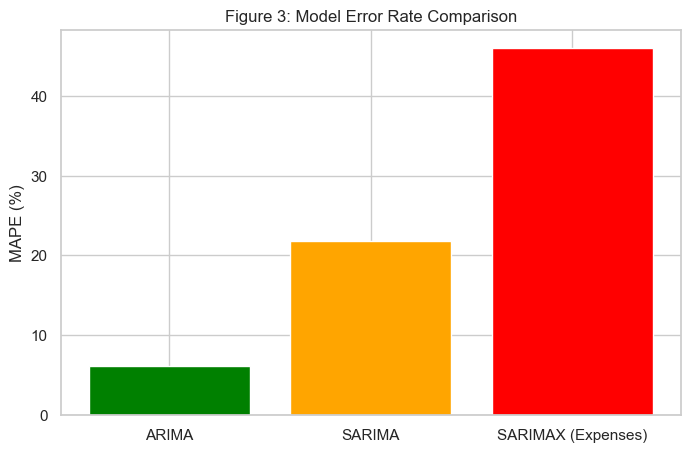

In [110]:
plt.figure(figsize=(8, 5))
plt.bar(comparison_results['Model'], [6.07, 21.77, 46.00], color=['green', 'orange', 'red'])
plt.ylabel('MAPE (%)')
plt.title('Figure 3: Model Error Rate Comparison')
plt.show()

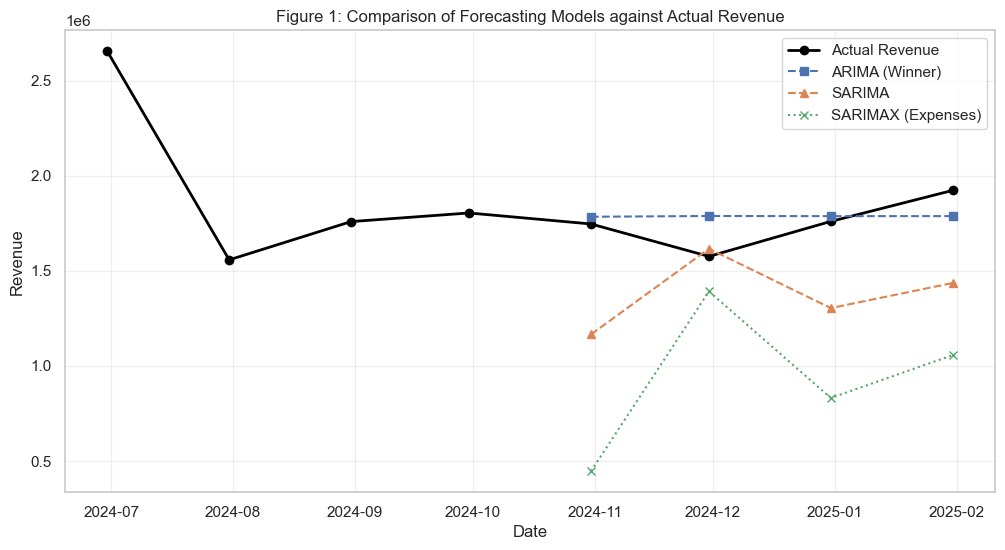

In [111]:


plt.figure(figsize=(12, 6))

# 1. Plot the actual data (Last 8 months for context)
plt.plot(df.index[-8:], df['Revenue'][-8:], label='Actual Revenue', color='black', linewidth=2, marker='o')

# 2. Plot ARIMA Forecast (Directly fitted and forecasted)
plt.plot(test.index, 
         SARIMAX(train['Revenue'], order=(1,1,1)).fit(disp=False).forecast(4), 
         label='ARIMA (Winner)', linestyle='--', marker='s')

# 3. Plot SARIMA Forecast
plt.plot(test.index, 
         SARIMAX(train['Revenue'], order=(1,1,1), seasonal_order=(0,1,0,12)).fit(disp=False).forecast(4), 
         label='SARIMA', linestyle='--', marker='^')

# 4. Plot SARIMAX Forecast (Using Expenses)
plt.plot(test.index, 
         SARIMAX(train['Revenue'], exog=train['Expenses'], order=(1,1,1), seasonal_order=(0,1,0,12))
         .fit(disp=False).get_forecast(4, exog=test['Expenses']).predicted_mean, 
         label='SARIMAX (Expenses)', linestyle=':', marker='x')

plt.title('Figure 1: Comparison of Forecasting Models against Actual Revenue')
plt.ylabel('Revenue')
plt.xlabel('Date')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()